# UTS Data Mining 2 — Soal Image: Clustering (dataset eksternal: Kaggle Flowers Recognition)

Dataset: **Flowers Recognition** — 4242 foto bunga asli, 5 kelas (daisy, dandelion, rose, sunflower, tulip), ukuran bervariasi (~320x240).

## Cara download (manual, sekali saja)
1. Buka **https://www.kaggle.com/datasets/alxmamaev/flowers-recognition** (perlu akun Kaggle, gratis) lalu klik **Download**.
2. Extract file zip-nya ke folder project ini (folder yang sama dengan notebook ini). Hasil extract-nya ada folder `flowers` yang di dalamnya berisi 5 subfolder kelas:
   ```
   Latihan UTS/
   ├── UTS_Clustering_Image_Flowers.ipynb
   └── flowers/
       ├── daisy/
       ├── dandelion/
       ├── rose/
       ├── sunflower/
       └── tulip/
   ```
   Tidak masalah kalau extract-nya jadi bersarang (mis. `flowers/flowers/daisy/...`) — cell di bawah otomatis mencari folder yang berisi ke-5 subfolder kelas itu.
3. Jalankan semua cell di bawah ini.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

np.random.seed(42)
CLASS_NAMES = ["daisy", "dandelion", "rose", "sunflower", "tulip"]

## 1. Cari & load data dari folder lokal

In [2]:
def find_flowers_dir(root, classes):
    """Cari folder yang berisi ke-5 subfolder kelas, berapa pun dalamnya nested."""
    for p in root.rglob("*"):
        if p.is_dir() and all((p / c).is_dir() for c in classes):
            return p
    return None


flowers_dir = find_flowers_dir(Path("."), CLASS_NAMES)
if flowers_dir is None:
    raise FileNotFoundError(
        "Folder dataset (berisi daisy/dandelion/rose/sunflower/tulip) tidak ketemu.\n"
        "Download & extract dulu sesuai instruksi di cell markdown paling atas."
    )
print(f"Dataset ditemukan di: {flowers_dir}")

Dataset ditemukan di: flowers


## 2. Subsample & load image

Ambil subsample seimbang per kelas supaya loading & clustering tetap cepat (silhouette score mahal dihitung untuk banyak sampel).

Total image dipakai: 1000 (target 200/kelas)


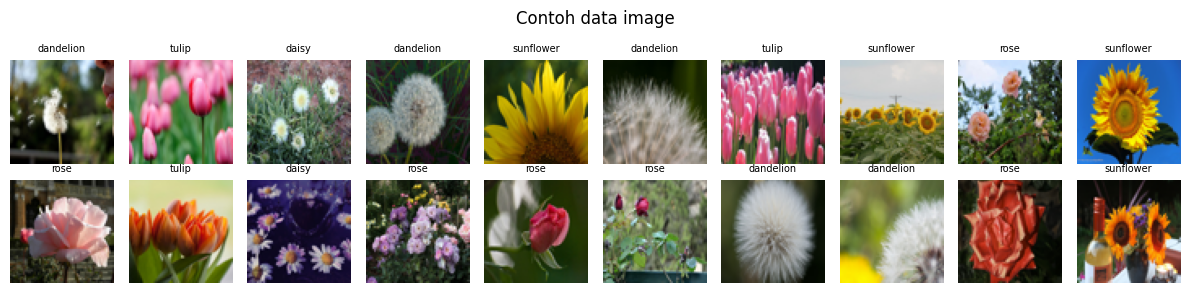

In [3]:
N_PER_CLASS = 200  # ubah ke angka lebih kecil kalau mau lebih cepat lagi
IMG_SIZE = 64       # resize semua image ke ukuran seragam
rng = random.Random(42)

paths, labels = [], []
for ci, cname in enumerate(CLASS_NAMES):
    files = sorted(p for p in (flowers_dir / cname).iterdir()
                    if p.suffix.lower() in (".jpg", ".jpeg", ".png"))
    sample = rng.sample(files, min(N_PER_CLASS, len(files)))
    paths.extend(sample)
    labels.extend([ci] * len(sample))

y_true = np.array(labels)


def load_image(path, size=IMG_SIZE):
    return np.asarray(Image.open(path).convert("RGB").resize((size, size)))


images = np.stack([load_image(p) for p in paths])
print(f"Total image dipakai: {images.shape[0]} (target {N_PER_CLASS}/kelas)")

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
preview_idx = rng.sample(range(len(paths)), 20)
for ax, i in zip(axes.flat, preview_idx):
    ax.imshow(images[i])
    ax.set_title(CLASS_NAMES[y_true[i]], fontsize=7)
    ax.axis("off")
plt.suptitle("Contoh data image")
plt.tight_layout()
plt.show()

## 3. Preprocessing & reduksi dimensi

In [4]:
X = images.reshape(images.shape[0], -1).astype(np.float64) / 255.0  # flatten, normalisasi [0,1]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained oleh 50 PC: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained oleh 50 PC: 74.0%


## 4. Tentukan jumlah cluster (Elbow + Silhouette)

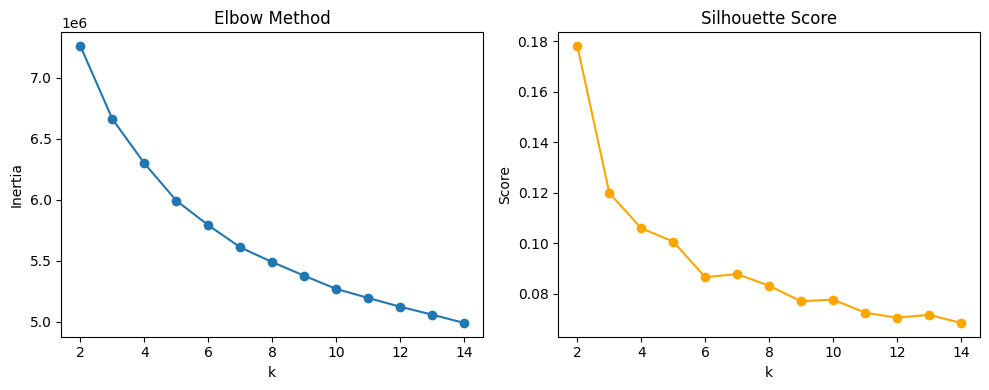

In [5]:
k_range = range(2, 15)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, "o-", color="orange")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

Dataset ini diketahui punya **5 kelas bunga asli**, jadi tetap pakai **k=5** supaya cluster bisa langsung dibandingkan ke kelas aslinya — meski k optimal menurut elbow/silhouette di atas bisa saja beda (foto bunga lebih mirip satu sama lain secara warna/komposisi dibanding digit).

## 5. Clustering final (KMeans, k=5) & evaluasi

In [6]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, cluster_labels)
dbi = davies_bouldin_score(X_pca, cluster_labels)
ari = adjusted_rand_score(y_true, cluster_labels)  # bonus: cocokkan vs label kelas asli

print(f"Silhouette Score : {sil:.3f}  (makin dekat 1 makin baik)")
print(f"Davies-Bouldin   : {dbi:.3f}  (makin dekat 0 makin baik)")
print(f"Adjusted Rand Idx: {ari:.3f}  (vs label kelas asli, 1 = cocok sempurna)")

Silhouette Score : 0.101  (makin dekat 1 makin baik)
Davies-Bouldin   : 2.342  (makin dekat 0 makin baik)
Adjusted Rand Idx: 0.033  (vs label kelas asli, 1 = cocok sempurna)


## 6. Visualisasi cluster (proyeksi PCA 2D)

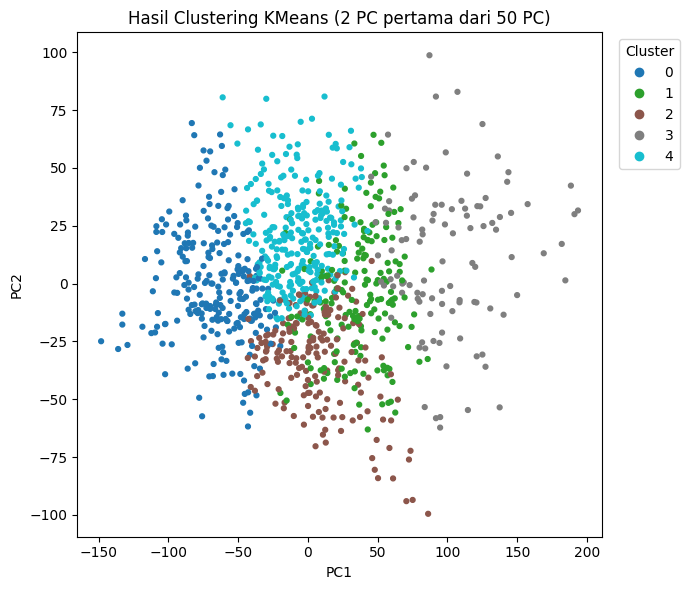

In [7]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", s=12)
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("Hasil Clustering KMeans (2 PC pertama dari 50 PC)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 7. Insight per cluster

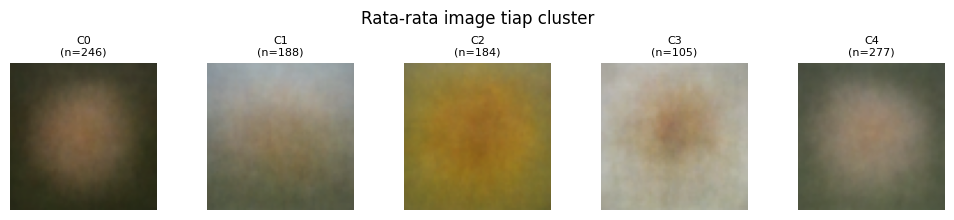

col_0,daisy,dandelion,rose,sunflower,tulip
Cluster,,,,,
0,65,52,56,29,44
1,33,32,27,49,47
2,7,35,22,82,38
3,22,19,26,19,19
4,73,62,69,21,52


In [8]:
fig, axes = plt.subplots(1, k, figsize=(10, 2.2))
for c in range(k):
    mean_img = images[cluster_labels == c].mean(axis=0).astype(np.uint8)
    axes[c].imshow(mean_img)
    axes[c].set_title(f"C{c}\n(n={np.sum(cluster_labels==c)})", fontsize=8)
    axes[c].axis("off")
plt.suptitle("Rata-rata image tiap cluster")
plt.tight_layout()
plt.show()

summary = pd.crosstab(cluster_labels, pd.Categorical.from_codes(y_true, CLASS_NAMES))
summary.index.name = "Cluster"
summary

In [9]:
for c in range(k):
    row = summary.loc[c]
    dominant = row.idxmax()
    purity = row.max() / row.sum()
    print(f"Cluster {c}: didominasi kelas '{dominant}' (purity {purity:.0%}, n={row.sum()})")

overall_purity = summary.max(axis=1).sum() / summary.values.sum()
print(f"\nOverall cluster purity: {overall_purity:.1%}")

Cluster 0: didominasi kelas 'daisy' (purity 26%, n=246)
Cluster 1: didominasi kelas 'sunflower' (purity 26%, n=188)
Cluster 2: didominasi kelas 'sunflower' (purity 45%, n=184)
Cluster 3: didominasi kelas 'rose' (purity 25%, n=105)
Cluster 4: didominasi kelas 'daisy' (purity 26%, n=277)

Overall cluster purity: 29.5%


## 8. Kesimpulan

- Silhouette & Davies-Bouldin mengukur kualitas cluster secara matematis tanpa label — jadi acuan utama evaluasi, sebelum dibandingkan ke label asli.
- Karena KMeans di sini jalan di atas piksel mentah (bukan fitur bentuk), cluster cenderung terbentuk berdasarkan **warna dominan**: `dandelion` (kuning) dan `sunflower` (kuning dengan pusat gelap) wajar sering tercampur dalam satu cluster, begitu juga `rose` dan `tulip` yang sama-sama punya varian warna merah/pink.
- Citra rata-rata tiap cluster (bag. 7) biasanya langsung kelihatan warna dominannya — itu sudah jadi insight visual tanpa perlu buka tiap foto satu-satu.
- Tabel crosstab + purity per cluster (data-driven) menunjukkan cluster mana paling "bersih" (didominasi satu jenis bunga) vs paling campur.
- `Adjusted Rand Index` cuma bonus pembanding ke label asli; evaluasi utama clustering murni tetap Silhouette & Davies-Bouldin.

Untuk PDF submission: screenshot plot elbow/silhouette (bag. 4), scatter PCA cluster (bag. 6), citra rata-rata + tabel crosstab (bag. 7), dan narasi insight di atas.